# Vacuum simulation

## 1. Delete water using `Modeller`
Delete waters from `data/ala2.pdb`

In [1]:
from openmm.app import Modeller, PDBFile
from src.param import param_unbiased_vaccuum

p = param_unbiased_vaccuum()
pdb_file = p.working_dir / "ala2_vac.pdb"

model_system = False
if model_system:
    pdb = PDBFile(p.pdb_file)
    modeller = Modeller(pdb.topology, pdb.positions)
    modeller.deleteWater()  # removes HOH/WAT residues
    # if you also added counter-ions, drop them too:
    ions = [r for r in modeller.topology.residues() if r.name in ("NA", "CL", "K")]
    modeller.delete(ions)
    modeller.topology.setPeriodicBoxVectors(None)  # optional: discard the box entirely

    top = modeller.topology
    vac_positions = modeller.positions

    with open(pdb_file, "w") as f:
        PDBFile.writeFile(top, vac_positions, f, keepIds=True)
else:
    vac_pdb = PDBFile(str(pdb_file))
    top = vac_pdb.topology
    vac_positions = vac_pdb.positions

## 2. Perform simulations and write dihedral & feature data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
from openmm.app import Simulation, ForceField, HBonds, NoCutoff

from src.data import simulation_data
from src.util import state_data_reporter, hdf5_reporter
from src.util import print_platform


def create_system(forcefield, topology):
    return forcefield.createSystem(
        topology,
        nonbondedMethod=NoCutoff,  # the "turn off PBC" switch
        constraints=HBonds,
        removeCMMotion=True,  # keeps the COM from drifting
    )


step_start = 9914  #  June 26-, 2026
num_steps = 15_000
do_simulation = True

if do_simulation:
    forcefield = ForceField("amber99sb.xml")
    system = create_system(forcefield, top)  # <- cleaned topology, not pdb.topology

    for step in range(step_start, num_steps):
        print(f"starting simulation {step} of {num_steps}")

        # start positions
        if step == 0:
            start_positions = vac_positions  # <- cleaned positions
        else:
            if step == step_start:
                sd = simulation_data(p, subdir=(step - 1))
            start_positions = sd.final_positions
        assert (
            type(start_positions) == mm.unit.quantity.Quantity
        ), f"ERROR: {type(start_positions) = } in step {step}"

        # new 'sd' object for present simulation files
        sd = simulation_data(p, subdir=step)
        outfile = str(sd.files["outfile"])
        h5file = str(sd.files["h5file"])

        # each step requires new integrator, simulation object
        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        simulation = Simulation(top, system, integrator)  # <- top, not pdb.topology
        print_platform(simulation)

        simulation.context.setPositions(start_positions)
        if step == 0:
            simulation.minimizeEnergy()  # minimize once, at the start
        simulation.context.setVelocitiesToTemperature(p.temperature)

        sdr = state_data_reporter(outfile, p.report_interval)
        hdr = hdf5_reporter(h5file, p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        simulation.step(round(p.simulation_time / p.timestep))

        for reporter in simulation.reporters:
            if hasattr(reporter, "close"):
                reporter.close()

        # save 'final_positions'
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({"final_positions": r})

        # calculate and save 'dihedrals', 'features' from 'h5file'
        sd.save_feature_data(recalculate=True)

starting simulation 7509 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7509/dihedrals.npy
writing data/vacuum/step_7509/features.npy
starting simulation 7510 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7510/dihedrals.npy
writing data/vacuum/step_7510/features.npy
starting simulation 7511 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7511/dihedrals.npy
writing data/vacuum/step_7511/features.npy
starting simulation 7512 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7512/dihedrals.npy
writing data/vacuum/step_7512/features.npy
starting simulation 7513 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7513/dihedrals.npy
writing data/vacuum/step_7513/features.npy
starting simulation 7514 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7514/dihedrals.npy
writing data/vacuum/step_7514/features.npy
starting simulation 7515 of 15000
Simulation platform: CUDA
writing data/vacuum/step_7515/dihedrals.npy
writing data/v

KeyboardInterrupt: 

## 3. Gather data from steps into master files

* Concatenate `dihedrals`, `features` arrays from each step
* Write combined data files to `p.working_dir`

sd.dihedrals.shape = (3000000, 2)
sd.features.shape = (3000000, 45)


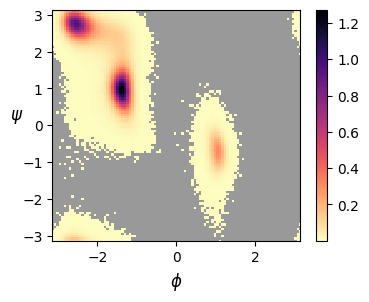

In [4]:
from src.grid2d import hist2d
from src.dataclass import data_class, DataClass
from src.plots import plot_dihedrals_hist2d

gather_data = False
if gather_data:
    dihedrals, features = [], []
    for step in range(num_steps):
        sd = simulation_data(p, subdir=step)
        dihedrals.append(sd.dihedrals)
        features.append(sd.features)

    sd = simulation_data(p)
    sd.save_and_assign_objects(
        {"dihedrals": np.vstack(dihedrals), "features": np.vstack(features)}
    )
else:
    sd = simulation_data(p)

theta = np.linspace(-np.pi, np.pi, 100)
pdf = DataClass(x=theta, y=theta, p=hist2d(theta, theta, sd.dihedrals))
pdf = data_class(sd.working_dir, "dihedrals_pdf", pdf)

print(f"{sd.dihedrals.shape = }")
print(f"{sd.features.shape = }")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_dihedrals_hist2d(fig, ax, pdf)
fig.savefig("notes/figures/unbiased-dih-hist2d-vac.png", bbox_inches="tight")

## 4. Train SRV

PyTorch version: 2.9.1+cu130
CUDA version (PyTorch): 13.0
CUDA available: True
CUDA device count: 1
Using device=device(type='cuda')


VAMPnet epoch:   0%|          | 0/5 [00:00<?, ?it/s]

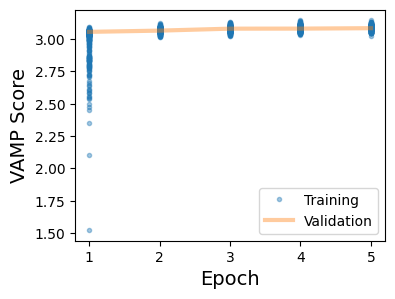

In [ ]:
from src.dataset import TrajectoryDataset, data_loaders
from src.vampnet import vampnet
from tqdm.notebook import tqdm

calculate = True
if calculate:
    num_epochs = 5
    dataset = TrajectoryDataset(sd.features)
    vn = vampnet(p, weighted=False)
    vn.fit(*data_loaders(dataset, p.frac_test), num_epochs=num_epochs, progress=tqdm)
    sd.save_and_assign_objects({"vampnet": vn})

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd.vampnet.train_scores.T, ".", alpha=0.4, label="Training")
ax.plot(*sd.vampnet.test_scores.T, "-", linewidth=3, alpha=0.4, label="Validation")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("VAMP Score", fontsize=14)
ax.legend()
fig.savefig("notes/figures/vampnet-vacuum.png", bbox_inches="tight")

/home/bharland/work/vac-metad/src/vampnet.py:333: RuntimeWarning: invalid value encountered in log
  return -self.lagtime / np.log(self.eigvals)


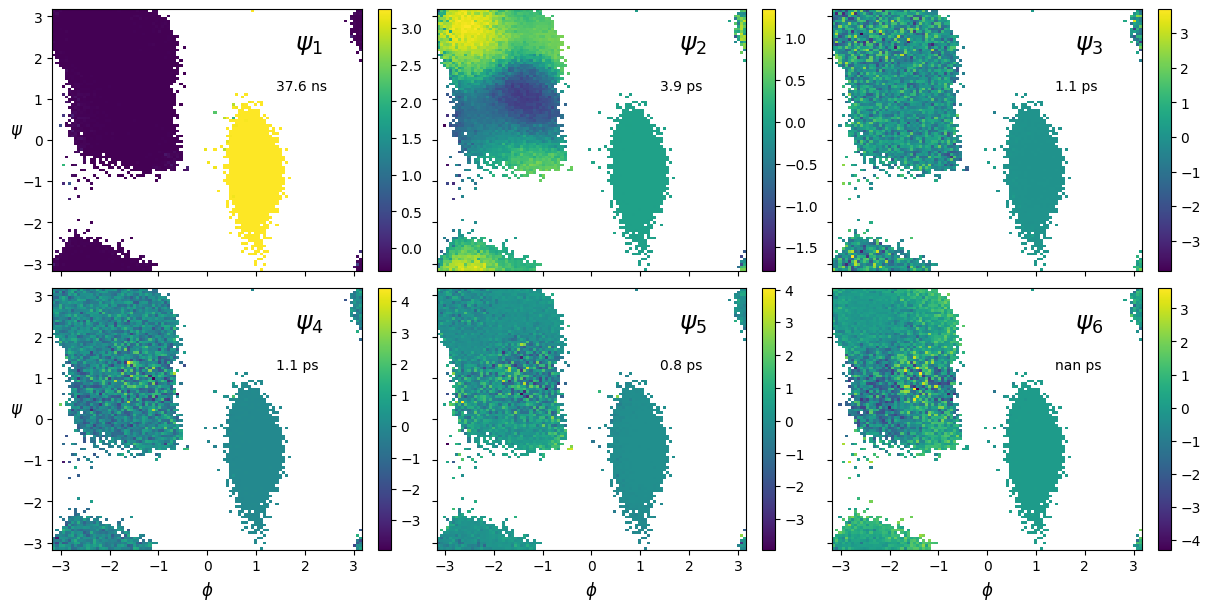

In [11]:
from src.vampnet import SRV
from src.plots import plot_eigfuncs

calculate = True
if calculate:
    srv = SRV(sd.vampnet.net, sd.lagtime)
    srv.fit(dataset)
    sd.save_eigen_data(srv)
    sd.save_grid_data(srv, num_points=100)

fig, axs = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True
)
plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)

## 5. ACFs

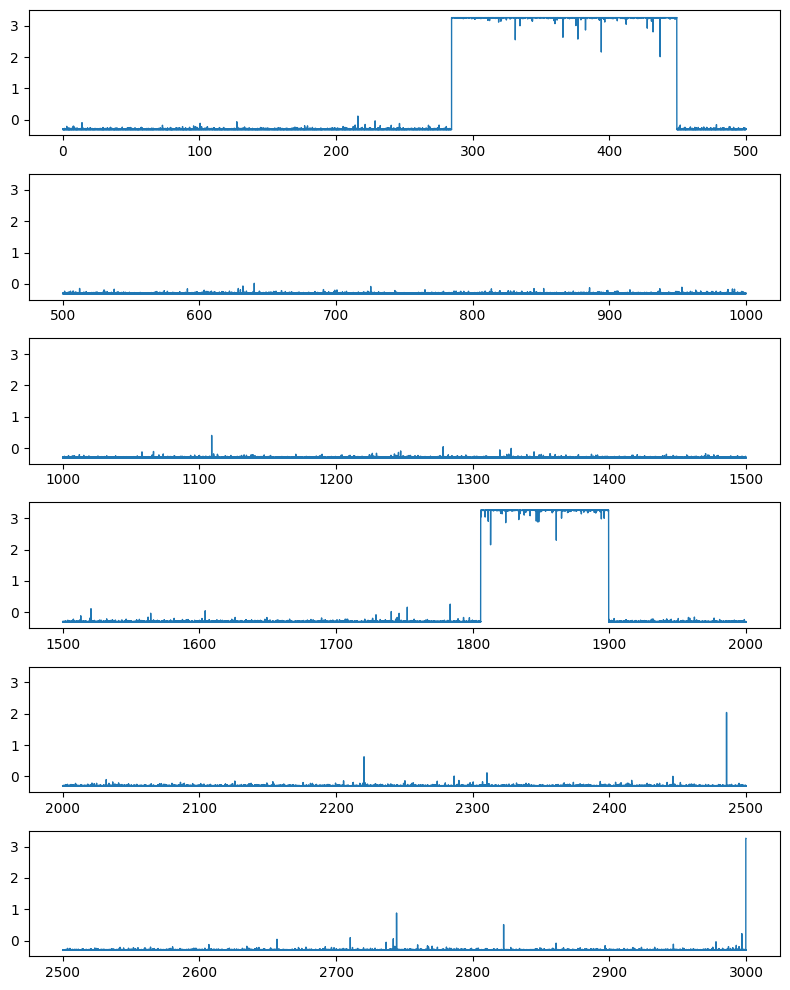

In [17]:
import openmm.unit as unit
from src.util import chunk_iter

ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond

num_chunks = 6
titer = chunk_iter(ns, num_chunks)
uiter = chunk_iter(sd.cvs[:, 0], num_chunks)

fig, axs = plt.subplots(num_chunks, 1, figsize=(8, 10))
for t, u, ax in zip(titer, uiter, axs):
    ax.set_ylim(-0.5, 3.5)
    ax.plot(t, u, lw=1)
fig.tight_layout()

Text(0, 0.5, 'C($\\tau$)')

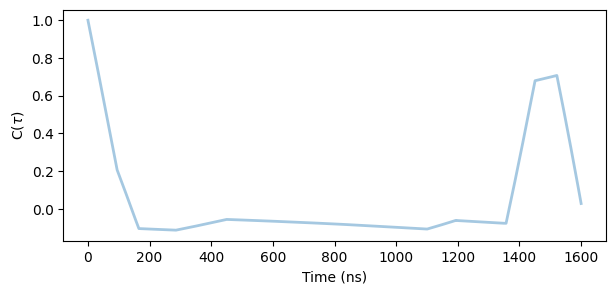

In [22]:
import importlib
import src.acf

importlib.reload(src.acf)

from src.acf import compute_acf_dataclass

ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond
num_frames_acf = 1_600_000  # 10 ns, too short, but similar to befoe
acf = compute_acf_dataclass(sd.cvs[:, 0], lagtime, num_frames_acf)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(ns[:num_frames_acf], acf.ct, lw=2, alpha=0.4)
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"C($\tau$)")

[warn] Sokal window never closed; using the full series (tau may be tail-contaminated). Use a longer trajectory or a smaller c_window.
[warn] Sokal window never closed; using the full series (tau may be tail-contaminated). Use a longer trajectory or a smaller c_window.


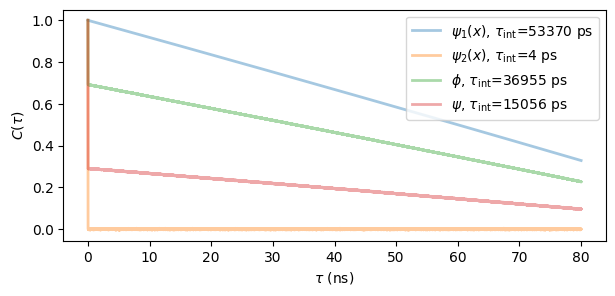

In [ ]:
from src.acf import compute_acfs

signals = {
    r"$\psi_1(x)$": sd.cvs[:, 0],
    r"$\psi_2(x)$": sd.cvs[:, 1],
    r"$\phi$": sd.dihedrals[:, 0],
    r"$\psi$": sd.dihedrals[:, 1],
}
acfs = compute_acfs(sd.working_dir, signals, lagtime, num_frames_acf, calculate=True)

num_frames = num_frames_acf
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for label, acf in acfs.items():
    ax.plot(
        ns[:num_frames],
        acf.ct[:num_frames],
        alpha=0.4,
        lw=2,
        label=rf"{label}, $\tau_\mathrm{{int}}$={acf.tau:.0f} ps",
    )
ax.set_xlabel(r"$\tau$ (ns)")
ax.set_ylabel(r"$C(\tau)$")
ax.legend()

In [14]:
sd.timescales

array([3.76259524e+04, 3.91537414e+00, 1.10717590e+00, 1.07225845e+00,
       7.56408053e-01,            nan])